In [ ]:
##-------------START------------------------##

##<font color="blue"><b>-----Supervised Fine-Tuning and Instruction Fine-Tuning-----</b></font>

### <font color="purple">**Problem Statement: Comparing Supervised Fine-Tuning and Instruction Fine-Tuning**</font>

Large Language Models (LLMs) can be adapted to follow specific tasks or a wider range of instructions through fine-tuning. In this demo experiment, we will compare **Supervised Fine-Tuning (SFT)** and **Instruction Fine-Tuning (IFT)** using the **Dolly-15K instruction-following dataset** and the **Qwen 0.5B language model**.

For **SFT**, we use only the **summarization** category from Dolly-15K. The model will therefore be fine-tuned for one specific task.

For **IFT**, we use examples from **all available categories** in Dolly-15K. The model will therefore be exposed to a diverse set of instruction-following tasks.

For both approaches, construct the model input using:

**Instruction + Context (optional) → Response**

The data, formatted using the Qwen chat template, tokenized and padded to a fixed length. During training, compute the loss only on the **response tokens**, while prompt tokens are ignored using the label value `-100`.

Train two separate models starting from the same pretrained Qwen 0.5B model:

- **SFT model:** trained on summarization examples.
- **IFT model:** trained on diverse instruction-following examples.



### <font color="purple">**Objective:**</font>

The objective of this experiment is to understand the practical difference between:

- **Task-specific fine-tuning (SFT)** — learning one particular task.
- **Instruction fine-tuning (IFT)** — learning to follow a diverse range of instructions.

We analyze the training behavior and generated responses of both models and discuss the advantages and limitations of each approach.

### <font color="purple">**Overall Flow is as follows:**</font>

<img src="https://raw.githubusercontent.com/Rekha215/Demo-Images/refs/heads/main/SFT_IFT.png" width="800">

In [ ]:
import os
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from torch.utils.data import TensorDataset, DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
DATASET      = "databricks/databricks-dolly-15k"
MODEL_NAME   = "Qwen/Qwen2.5-0.5B"
MAX_LEN      = 512
IGNORE_INDEX = -100
BATCH_SIZE   = 16
SEED         = 42

In [ ]:
set_seed(SEED)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [ ]:
ift_data = load_dataset(DATASET, split="train")
ift_df   = ift_data.to_pandas()
sft_df = ift_df[ift_df["category"] == "summarization"].reset_index(drop=True)

ift_train = ift_df.groupby("category").sample(n=10, random_state=SEED)
ift_test  = ift_df.drop(ift_train.index).groupby("category").sample(n=2, random_state=SEED)

sft_train = sft_df.sample(n=50, random_state=SEED)
sft_test  = sft_df.drop(sft_train.index).sample(n=10, random_state=SEED)

print("IFT train/test:", ift_train.shape, ift_test.shape)
print("SFT train/test:", sft_train.shape, sft_test.shape)

README.md:   0%|          | 0.00/8.20k [00:00<?, ?B/s]

databricks-dolly-15k.jsonl: reconstructing file:   0%|          |  0.00B / 13.1MB            

databricks-dolly-15k.jsonl: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

IFT train/test: (80, 4) (16, 4)
SFT train/test: (50, 4) (10, 4)


In [ ]:
ift_test.head(16)

,instruction,context,response,category
2919,Give me a list of 10 commonly used seasonings ...,,Soy Sauce\nOyster Sauce\nChinese Cooking Wine\...,brainstorming
3625,What are a few things to do when visiting Nort...,,Here are some to do when visiting Northern Vie...,brainstorming
13411,"Who amongst these are women: Virat Kohli, Roge...",,"Serena Williams, PV Sindhu, Maria Sharapova, S...",classification
14444,Classify each of the following as either a spo...,,porsche cayman: sports car\nsubaru brz: sports...,classification
13771,Given a reference text about Ainley's storm pe...,Ainley's storm petrel (Hydrobates cheimomneste...,Ainley's storm petrel breed on Guadalupe Islan...,closed_qa
313,What's the game engine used by Bethesda before...,After using the Gamebryo engine to create The ...,Gamebryo was the engine used by Bethesda befor...,closed_qa
10919,Ram was asked to repeat after the speaker. Spe...,,"Haha, that's a nice one. While Ram was asked t...",creative_writing
11381,List the ingredients and step by step instruct...,,Ingredients:\n3/4 oz vodka\n3/4 oz rum\n3/4 oz...,creative_writing
2132,What kind of boat should I purchase?,,There are a large variety of options in recrea...,general_qa
11643,When do avalanches occur?,,Avalanches are primarily caused by unstable sn...,general_qa


In [ ]:
sft_test.head()

,instruction,context,response,category
824,Who is Pana Chand Meghwal,Pana Chand Meghwal is an Indian politician fro...,Pana Chand Meghwal is an Indian politician fro...,summarization
948,Can you summarize for me in no more than three...,The Little Engine That Could is an American fo...,The Little Engine That Could is a children's b...,summarization
303,What is the total number of geographical entit...,This is a list of sovereign states and depende...,"There are 56 sovereign states, 2 non-sovereign...",summarization
1088,Who coined the term lipstick index and what do...,The lipstick index is a term coined by Leonard...,The lipstick index is a term coined by Leonard...,summarization
350,Provide some key points on Cardiac surgery fro...,"Cardiac surgery, or cardiovascular surgery, is...","1. Cardiac surgery, often known as cardiovascu...",summarization


In [ ]:
# ===========================================================================
#    Build TensorDatasets
#    IFT: instruction + context   |   SFT: instruction only + context
# ===========================================================================
def build_dataset(df, use_context):
    input_ids_list, attention_list, labels_list = [], [], []

    for _, row in df.iterrows():
        if use_context and row["context"].strip():
            user_msg = row["instruction"] + "\n\n" + row["context"]
        else:
            user_msg = row["instruction"]

        # Chat template -> text, then tokenize to plain int lists
        prompt_text = tokenizer.apply_chat_template(
            [{"role": "user", "content": user_msg}],
            tokenize=False, add_generation_prompt=True,
        )
        full_text = tokenizer.apply_chat_template(
            [{"role": "user", "content": user_msg},
             {"role": "assistant", "content": row["response"]}],
            tokenize=False, add_generation_prompt=False,
        )

        prompt_ids = tokenizer(prompt_text, add_special_tokens=False)["input_ids"]
        full_ids   = tokenizer(full_text,   add_special_tokens=False)["input_ids"]

        full_ids   = full_ids[:MAX_LEN]
        prompt_len = min(len(prompt_ids), len(full_ids))

        # Mask the prompt, keep loss on the response
        labels = [IGNORE_INDEX] * prompt_len + full_ids[prompt_len:]

        # Pad to MAX_LEN
        pad_n     = MAX_LEN - len(full_ids)
        attention = [1] * len(full_ids) + [0] * pad_n
        full_ids  = full_ids + [tokenizer.pad_token_id] * pad_n
        labels    = labels   + [IGNORE_INDEX] * pad_n

        input_ids_list.append(torch.tensor(full_ids))
        attention_list.append(torch.tensor(attention))
        labels_list.append(torch.tensor(labels))

    return TensorDataset(
        torch.stack(input_ids_list),
        torch.stack(attention_list),
        torch.stack(labels_list),
    )

ift_train_ds = build_dataset(ift_train, use_context=True)
ift_test_ds  = build_dataset(ift_test,  use_context=True)

sft_train_ds = build_dataset(sft_train, use_context=True)
sft_test_ds  = build_dataset(sft_test,  use_context=True)

print("IFT sizes:", len(ift_train_ds), len(ift_test_ds))
print("SFT sizes:", len(sft_train_ds), len(sft_test_ds))

IFT sizes: 80 16
SFT sizes: 50 10


In [ ]:
# ===========================================================================
# Wrap TensorDataset -> dict for Trainer
# ===========================================================================
class DictDataset(Dataset):
    def __init__(self, tensor_ds):
        self.ds = tensor_ds
    def __len__(self):
        return len(self.ds)
    def __getitem__(self, i):
        input_ids, attention_mask, labels = self.ds[i]
        return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

In [ ]:
# ===========================================================================
# Reusable training
# ===========================================================================
def run_training(model, train_ds, val_ds, out_dir):
    args = TrainingArguments(
        output_dir=out_dir,
        num_train_epochs=3,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        learning_rate=5e-5,
        logging_strategy="epoch",      # log train loss once per epoch
        eval_strategy="epoch",
        save_strategy="epoch",
        report_to=[],
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=DictDataset(train_ds),
        eval_dataset=DictDataset(val_ds),
    )
    trainer.train()
    trainer.save_model(out_dir)
    metrics = trainer.evaluate()
    print(f"\nFinal validation metrics ({out_dir}):", metrics)
    return trainer

In [ ]:
# --- SFT ---
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
sft_trainer = run_training(model, sft_train_ds, sft_test_ds, "./sft_out")

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss
1,1.076804,1.432097
2,0.564808,1.431818
3,0.523873,1.433861


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch
0.523873,1.433861,3



Final validation metrics (./sft_out): {'eval_loss': 1.4338608980178833}


In [ ]:
# --- IFT ---
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)   # reload base weights
ift_trainer = run_training(model, ift_train_ds, ift_test_ds, "./ift_out")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss
1,2.269074,1.952627
2,1.437756,1.913945
3,1.157560,1.906893


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch
1.157560,1.906893,3



Final validation metrics (./ift_out): {'eval_loss': 1.9068926572799683}


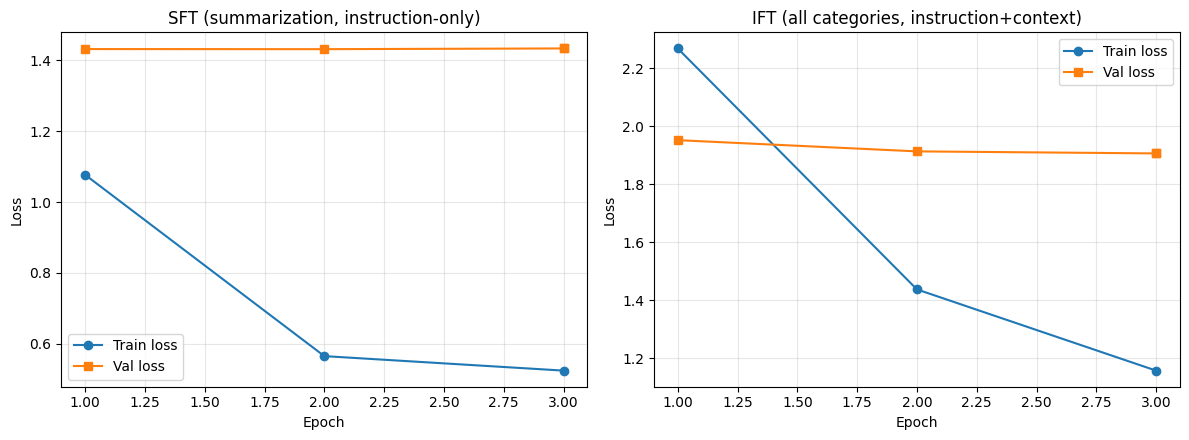

In [ ]:
def get_loss_curves(trainer):
    train_epochs, train_loss = [], []
    val_epochs,   val_loss   = [], []
    for rec in trainer.state.log_history:
        if "loss" in rec and "eval_loss" not in rec:
            train_epochs.append(rec["epoch"])
            train_loss.append(rec["loss"])
        if "eval_loss" in rec:
            val_epochs.append(rec["epoch"])
            val_loss.append(rec["eval_loss"])
    return train_epochs, train_loss, val_epochs, val_loss

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, trainer, title in [
    (axes[0], sft_trainer, "SFT (summarization, instruction-only)"),
    (axes[1], ift_trainer, "IFT (all categories, instruction+context)"),
]:
    te, tl, ve, vl = get_loss_curves(trainer)
    ax.plot(te, tl, marker="o", label="Train loss")
    ax.plot(ve, vl, marker="s", label="Val loss")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ===========================================================================
# Generation helper
# ===========================================================================
@torch.no_grad()
def generate_answer(model, user_msg, max_new_tokens=200):
    model.eval()
    prompt_text = tokenizer.apply_chat_template(
        [{"role": "user", "content": user_msg}],
        tokenize=False, add_generation_prompt=True,
    )
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=tokenizer.pad_token_id)
    # Slice off the prompt, decode only the newly generated tokens
    gen_ids = out[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

# ===========================================================================
# Compare on 5 samples
# ===========================================================================
def build_user_msg(row, use_context):
    if use_context and row["context"].strip():
        return row["instruction"] + "\n\n" + row["context"]
    return row["instruction"]

sft_model = sft_trainer.model
ift_model = ift_trainer.model

# SFT: 5 samples from the summarization test set
print("=" * 80)
print("SFT MODEL — 5 summarization samples (instruction + context)")
print("=" * 80)
for i, (_, row) in enumerate(sft_test.head(5).iterrows(), 1):
    out = generate_answer(sft_model, build_user_msg(row, use_context=True))
    print(f"\n--- Sample {i}  [{row['category']}] ---")
    print("INSTRUCTION :", row["instruction"])
    print("GOLD        :", row["response"])
    print("SFT OUTPUT  :", out)

# IFT: 5 samples from the mixed test set, each a different category
print("\n" + "=" * 80)
print("IFT MODEL — 5 samples across categories (instruction + context)")
print("=" * 80)
ift_samples = ift_test.groupby("category").head(1).head(5)
for i, (_, row) in enumerate(ift_samples.iterrows(), 1):
    out = generate_answer(ift_model, build_user_msg(row, use_context=True))
    print(f"\n--- Sample {i}  [{row['category']}] ---")
    print("INSTRUCTION :", row["instruction"])
    print("GOLD        :", row["response"])
    print("IFT OUTPUT  :", out)

SFT MODEL — 5 summarization samples (instruction + context)

--- Sample 1  [summarization] ---
INSTRUCTION : Who is Pana Chand Meghwal
GOLD        : Pana Chand Meghwal is an Indian politician from the Indian National Congress and former member of the Rajasthan Legislative Assembly. He was elected to represent the Baran-Atru Constituency.
SFT OUTPUT  : Pana Chand Meghwal is an Indian politician from the Indian National Congress and former member of the Rajasthan Legislative Assembly. He was elected to represent the Baran-Atru Constituency. He resigned from Rajasthan assembly on 15 August 2022. Miffed over cases of alleged atrocities on dalits, Congress MLA Pana Chand Meghwal sent his resignation to chief minister Ashok Gehlot, saying he does not have the right to stay as an MLA if he cannot protect the rights of his community.слуша
 técn
Pana Chand Meghwal is an Indian politician from the Indian National Congress and former member of the Rajasthan Legislative Assembly. He was elected to

### **Summary**

* **SFT** adapts a pretrained language model to a **specific task** using supervised instruction–response examples.
* **IFT** exposes the model to **multiple types of instructions**, helping it learn a broader instruction-following behavior.
* The fine-tuning process involves **preparing instruction–context–response data, applying a chat template, tokenizing the data, and computing loss only on response tokens**.
* The generated examples demonstrate that **the training data strongly influences how a fine-tuned model responds to different types of instructions**.


### **Future Directions**

1. **Use larger training datasets** to study how the performance of SFT and IFT changes with more training examples.

2. **Evaluate on more diverse and unseen tasks** to better measure the generalization ability of the fine-tuned models.

3. **Compare different pretrained LLMs** to investigate whether the observed behavior is consistent across model architectures and sizes.

4. **Use more comprehensive evaluation metrics** to compare generated responses in terms of accuracy, relevance, fluency, and instruction-following ability.


In [ ]:
##-------------END------------------------##